In [88]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl

In [89]:
N_particles = 500

mpl.rcParams.update({
    # Font (gnuplot ≈ Helvetica)
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],

    # Dimensioni testo
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 9,

    # Linee
    "lines.linewidth": 1.8,

    # Assi
    "axes.linewidth": 1.0,

    # Griglia (stile gnuplot)
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "grid.alpha": 0.7,

    # Legenda
    "legend.frameon": True,
    "legend.fancybox": False,
    "legend.framealpha": 1.0,
    "legend.edgecolor": "black",
    "legend.facecolor": "white"
})


In [90]:
def autocorrelation_time(data, max_lag=None):

    data = np.asarray(data)
    N = len(data)

    if max_lag is None:
        max_lag = N // 2

    mean = np.mean(data)
    var = np.var(data)

    if var == 0:
        return 0.0

    autocorr = []

    for t in range(max_lag):
        c = np.mean((data[:N - t] - mean) * (data[t:] - mean)) / var
        autocorr.append(c)

    autocorr = np.array(autocorr)

    # sum until autocorrelation is positive
    positive = autocorr[1:][autocorr[1:] > 0]

    tau = 0.5 + np.sum(positive)
    return tau


In [91]:
def pot_neg(x,lamb):
    return np.pow(x,-12) - np.pow(x,-6) - lamb/x

def pot_pos(x,lamb):
    return np.pow(x,-12) - np.pow(x,-6) + lamb/x


TypeError: Legend.__init__() got an unexpected keyword argument 'location'

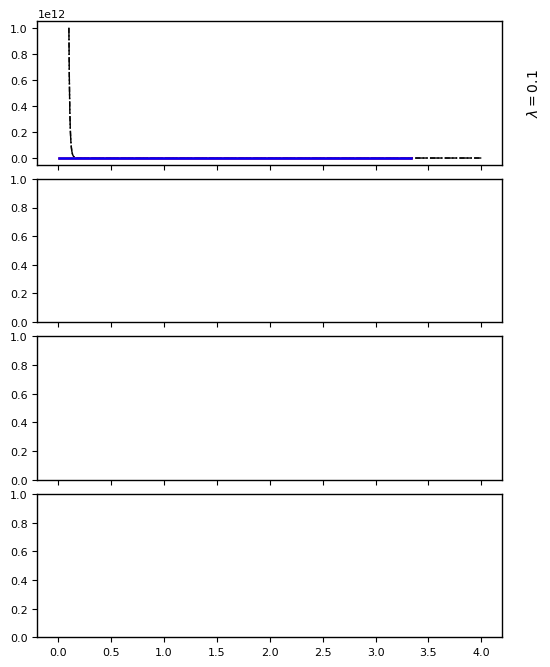

In [ ]:
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator

# 43%, 43%, 0.42%, 0.41%
lamb = [0.1, 1,5,10]
n_lamb = np.size(lamb)

x = np.linspace(0.1,4,10000)

fig, axes = plt.subplots(n_lamb, 1, figsize=(6, 2*n_lamb),sharex=True)
fig.subplots_adjust(hspace=0.1) 

for i in range(0,n_lamb):
    l = lamb[i]
    y = pot_neg(x,l)
    y_2 = pot_pos(x,l)
    
    axes[i].plot(x,y,
        c="k",
        linestyle='--',
        linewidth=1,
        alpha=1,
        label="+- Pot")
    
    axes[i].plot(x,y_2,
        c="k",
        linestyle='-.',
        linewidth=1,
        alpha=1,
        label="++ Pot")
    
    data_differ = np.loadtxt(f"./lambda{l}/radial_distribution_differ.csv", delimiter=";")
    axes[i].plot(data_differ[:,0], data_differ[:,1],c="red", label=r"$g_{+-}$")

    data_same = np.loadtxt(f"./lambda{l}/radial_distribution_equal.csv", delimiter=";")
    axes[i].plot(data_same[:,0], data_same[:,1],c="blue", label =r"$g_{++}$")

    axes[i].text(
        1.05, 0.5,               # coordinate in frazione dell'asse
        rf'$\lambda = {l}$',
        transform=axes[i].transAxes,  # usa coordinate relative all'asse
        rotation=90,
        va='center',             # allineamento verticale
        ha='left'                # allineamento orizzontale
    )
    if i != n_lamb-1:
        axes[i].tick_params(axis='x', labelbottom=False)
    
    if i == 0:
        axes[i].legend()

    axes[i].xaxis.minorticks_on()
    axes[i].yaxis.minorticks_on()

    axes[i].set_xlim([0,3])
    axes[i].set_ylim([-1,5])
    axes[i].grid()
    
plt.show()
